In [47]:
pip install pandas scikit-learn underthesea

Note: you may need to restart the kernel to use updated packages.


In [48]:
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv('review_aspect.csv')

# Các cột chứa khía cạnh (aspect)
aspect_cols = ['chat_luong', 'dong_goi', 'van_chuyen', 'gia_ca', 'overall']

# 2. Chuyển dữ liệu sang dạng Long Format bằng hàm melt
df_long = pd.melt(
    df,
    id_vars=['comment'],           # Cột giữ nguyên
    value_vars=aspect_cols,        # Các cột muốn biến thành hàng
    var_name='aspect',             # Tên cột mới chứa tên khía cạnh
    value_name='sentiment'         # Tên cột mới chứa nhãn cảm xúc
)

# Xóa các hàng có comment bị NaN (nếu có)
df_long = df_long.dropna(subset=['comment'])

print(df_long.head())

                                            comment      aspect sentiment
0  Chất lượng sản phẩm: dày dặn... màu tô khác hình  chat_luong  positive
1        Chưa dùng... đóng gói cẩn thận, giao nhanh  chat_luong   neutral
2                                 Bài viết JISOO...  chat_luong   neutral
3                             Đẹp, màu xinh, khó tô  chat_luong  positive
4                                  Sản phẩm móp méo  chat_luong  negative


In [49]:
import re
from underthesea import word_tokenize

def preprocess_text(text):
    # 1. Chuyển về chữ thường (Lowercasing)
    text = str(text).lower()

    # 2. Loại bỏ dấu câu và ký tự đặc biệt (chỉ giữ lại chữ cái và số)
    text = re.sub(r'[^\w\s]', ' ', text)

    # 3. Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Tách từ tiếng Việt (Word Segmentation)
    # Ví dụ: "giao hàng" -> "giao_hàng"
    text = word_tokenize(text, format="text")

    return text

# Áp dụng hàm cho cột comment
df_long['clean_comment'] = df_long['comment'].apply(preprocess_text)

In [50]:
# Tạo format: "câu_bình_luận [ASPECT=tên_khía_cạnh]"
df_long['final_input'] = df_long['clean_comment'] + " [ASPECT=" + df_long['aspect'] + "]"

# Xem thử kết quả
print(df_long[['final_input', 'sentiment']].head())

                                         final_input sentiment
0  chất_lượng sản_phẩm dày_dặn màu tô khác hình [...  positive
1  chưa dùng đóng_gói cẩn_thận giao nhanh [ASPECT...   neutral
2                 bài viết jisoo [ASPECT=chat_luong]   neutral
3            đẹp màu xinh_khó tô [ASPECT=chat_luong]  positive
4               sản_phẩm móp méo [ASPECT=chat_luong]  negative


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Chia Train / Test (Tỉ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    df_long['final_input'],
    df_long['sentiment'],
    test_size=0.2,
    random_state=42
)

# 2. Cài đặt TF-IDF (Sử dụng cả unigram và bigram như proposal)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

# Chuyển đổi dữ liệu
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Kích thước ma trận Train:", X_train_tfidf.shape)

Kích thước ma trận Train: (7208, 5000)


In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore') # Ẩn bớt các cảnh báo lặt vặt

print("⏳ Đang cắm máy để 'Train kĩ' (GridSearchCV + 5-Fold Cross Validation)...")

# 1. Định nghĩa không gian tham số (Lưới kịch bản) mà mình muốn máy thử nghiệm
# C: Độ mạnh của thuật toán chống học vẹt (L2 Regularization)
# class_weight: Cân bằng trọng số hoặc không
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear', 'lbfgs'] # Các thuật toán giải toán khác nhau
}

# 2. Khởi tạo mô hình cơ sở
base_log_reg = LogisticRegression(max_iter=2000, random_state=42)

# 3. Gắn mô hình vào bộ dò tìm (GridSearchCV)
# cv=5: Băm dữ liệu làm 5 khúc để train chéo
# scoring='f1_macro': Mục tiêu là làm sao đẩy điểm F1 trung bình lên cao nhất
grid_search = GridSearchCV(
    estimator=base_log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1, # Tận dụng tối đa số luồng (CPU cores) của máy để chạy cho nhanh
    verbose=1  # In tiến trình ra màn hình
)

# 4. BẮT ĐẦU HUẤN LUYỆN KĨ
grid_search.fit(X_train_tfidf, y_train)

# ==========================================
# 5. KẾT QUẢ CỦA QUÁ TRÌNH TỐI ƯU HÓA
# ==========================================
print("\n✅ TÌM KIẾM THÀNH CÔNG!")
print(f"👉 Tham số xịn nhất mà máy tìm được là: {grid_search.best_params_}")

# Lấy ra mô hình hoàn hảo nhất sau khi dò tìm
best_model = grid_search.best_estimator_

# Chạy thử mô hình xịn trên tập Test
y_pred_best = best_model.predict(X_test_tfidf)

print("\n🏆 BẢNG ĐIỂM SAU KHI TRAIN KĨ:")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best, zero_division=0))

⏳ Đang cắm máy để 'Train kĩ' (GridSearchCV + 5-Fold Cross Validation)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ TÌM KIẾM THÀNH CÔNG!
👉 Tham số xịn nhất mà máy tìm được là: {'C': 1.0, 'class_weight': None, 'solver': 'lbfgs'}

🏆 BẢNG ĐIỂM SAU KHI TRAIN KĨ:
              precision    recall  f1-score   support

    negative       0.83      0.88      0.85       376
     neutral       0.82      0.85      0.83       942
    positive       0.78      0.69      0.73       484

    accuracy                           0.81      1802
   macro avg       0.81      0.81      0.81      1802
weighted avg       0.81      0.81      0.81      1802



⏳ Đang huấn luyện các mô hình (Phiên bản cân bằng dữ liệu)...
✅ Huấn luyện xong!

🏆 KẾT QUẢ LOGISTIC REGRESSION (ĐÃ DÙNG CLASS_WEIGHT):
Accuracy: 0.7880133185349611
              precision    recall  f1-score   support

    negative       0.77      0.90      0.83       376
   negative        0.00      0.00      0.00         0
     neutral       0.86      0.74      0.80       942
    positive       0.70      0.80      0.75       484

    accuracy                           0.79      1802
   macro avg       0.58      0.61      0.59      1802
weighted avg       0.80      0.79      0.79      1802

--------------------------------------------------
🥈 KẾT QUẢ NAIVE BAYES (Baseline):
Accuracy: 0.6470588235294118
              precision    recall  f1-score   support

    negative       0.68      0.23      0.34       376
     neutral       0.64      0.77      0.70       942
    positive       0.66      0.73      0.70       484

    accuracy                           0.65      1802
   macro avg  

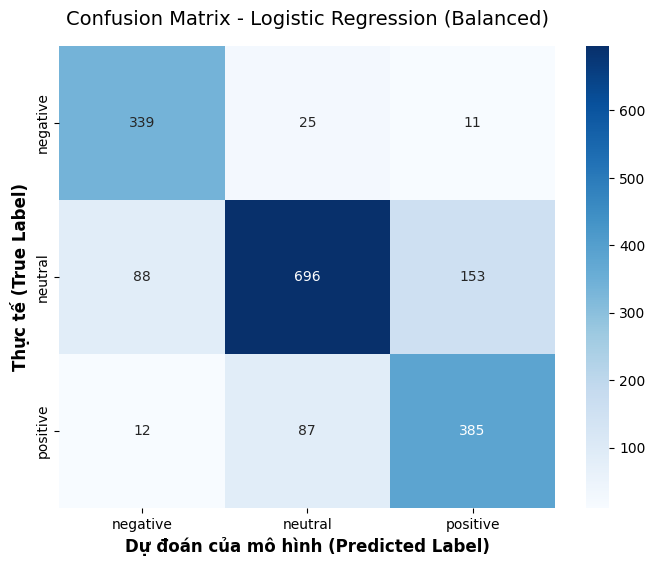

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==========================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH (TRAIN)
# ==========================================
print("⏳ Đang huấn luyện các mô hình (Phiên bản cân bằng dữ liệu)...")

# 1.1 Logistic Regression ĐÃ NÂNG CẤP (Thêm class_weight='balanced')
log_reg_balanced = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced', # <--- Khắc phục yếu điểm nhãn Positive
    max_iter=1000,
    random_state=42
)
log_reg_balanced.fit(X_train_tfidf, y_train)

# 1.2 Naive Bayes (Vẫn giữ làm Baseline Model để so sánh)
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_tfidf, y_train)

print("✅ Huấn luyện xong!\n")

# ==========================================
# 2. DỰ ĐOÁN VÀ ĐÁNH GIÁ (EVALUATE)
# ==========================================

# Logistic Regression (Bản xịn) dự đoán
y_pred_lr_bal = log_reg_balanced.predict(X_test_tfidf)

# Naive Bayes dự đoán
y_pred_nb = naive_bayes.predict(X_test_tfidf)

# ==========================================
# 3. IN BẢNG ĐIỂM (CLASSIFICATION REPORT)
# ==========================================
print("🏆 KẾT QUẢ LOGISTIC REGRESSION (ĐÃ DÙNG CLASS_WEIGHT):")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_bal))
print(classification_report(y_test, y_pred_lr_bal, zero_division=0))

print("-" * 50)

print("🥈 KẾT QUẢ NAIVE BAYES (Baseline):")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, zero_division=0))

# ==========================================
# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
print("📊 Đang vẽ Confusion Matrix cho Logistic Regression...")

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_lr_bal, labels=['negative', 'neutral', 'positive'])

# Thiết lập kích thước và vẽ biểu đồ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # Hiển thị số lượng bên trong từng ô
    fmt='d',             # Định dạng số nguyên (integer)
    cmap='Blues',        # Dùng tông màu xanh cho chuyên nghiệp
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

# Thêm tiêu đề và nhãn dán
plt.xlabel('Dự đoán của mô hình (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('Thực tế (True Label)', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Logistic Regression (Balanced)', fontsize=14, pad=15)

# Hiển thị biểu đồ
plt.show()